<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#5642C5;
           font-size:200%;
           font-family:Arial;letter-spacing:0.5px">

<p width = 20%, style="padding: 10px;
              color:white;">
Neural Networks: Keras and Tensorflow
</p>
</div>

DS-NTL-010824<p>Phase 4</p>
<br>
<br>

<div align = "right">
<img src="Images/flatiron-school-logo.png" align = "right" width="200"/>
</div>
    
    

In [1]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits, load_sample_images

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns


#### Neural Networks: Packages

When manually implementing:

- have to keep track of forward and backwards propagation for each layer:
    - equations and updates depends on specific layer activations
- manage caching updates to gradients and weights/activations appropriately

**Deep Learning frameworks take care of this for us**

In addition:

- efficient matrix math for speedup.
- use variants of gradient descent that are **much** faster/better.

Major frameworks:

<img src = "Images/kerastf.png" >
<center> Keras: high level API of Tensorflow. </center>

- Keras: apt for quickly building/trying neural network architectures with standard layers/optimizers. Still build complex networks.
- Tensorflow: for building more customized networks and more control of optimization.

<center><img src = "Images/pytorch.png" >
More customizable than Keras. More pythonic than base Tensorflow. Nice functionalities for NLP. </center>


We will use Keras.

In [2]:
from tensorflow import keras

Keras has two major neural network construction frameworks:
- Sequential vs Functional API

Sequential API:

<img src = "Images/sequentialvsfunctional.png" >

<center>Apt for simpler feedforward network topologies.</center>

Functional API:

<center><img src = "Images/skipconnection.png" ></center>

Skip connections, branching, etc.


#### The Sequential API

Take in a simple and sufficiently interesting dataset:

- demonstrate non-trivial decision boundary
- show sequential API at work

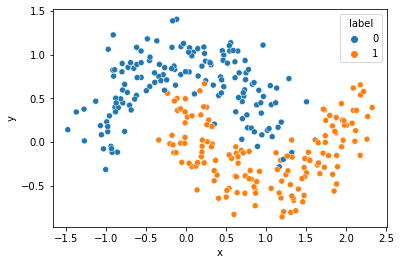

In [3]:
# generate two moons dataset
import seaborn as sns
from sklearn.datasets import make_moons
from matplotlib import pyplot
from pandas import DataFrame
# generate 2d classification dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=10)
# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))

sns.scatterplot(x = 'x', y = 'y', hue = 'label', data = df )
plt.show()

Import Sequential object: use Sequential API to construct models

In [4]:
from tensorflow.keras.models import Sequential

We want to start defining layers in the model:
    
The most common layer type in neural networks: 
- the **densely** connected layer

<img src = "Images/dense_layer.png" >

In [5]:
# creates densely connected layer object
from tensorflow.keras.layers import Dense

# defines input layer, not necessary in sequential API
# but nice for visualizing network later
from tensorflow.keras.layers import Input 

The Dense object constructor's basic arguments:
- units: number of nodes in layer
- activation: 'relu', 'tanh', 'sigmoid', 'softmax'


Defining the model: a shallow neural network

In [6]:
model = Sequential()
model.add(Dense(50, input_dim=2, activation='relu')) # one hidden layer
model.add(Dense(units=1, activation='sigmoid'))

Building/compiling the model:

- define objective function and optimizer
- define metric to evaluate train/validation
- build the network connections, weight matrices, initializes, etc.

In [7]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy', 'AUC'])

Some other loss functions:
- multiclass: 'categorical_crossentropy'
- regression: 'mean_squared_error'
- regression: 'mean_absolute_error'

The optimizer:

- Adam Optimizer: 
    - smoothens learning process 
    - uses adaptive learning rate.

A pretty good optimizer. Many other optimizers (NAdam, Adadelta).

#### Optimizers have hyperparameters.

- Can help in training speed up / finding minimum

model.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['accuracy', 'AUC'])

In [8]:
from tensorflow.keras.optimizers import Adam

In [9]:
opt = Adam(learning_rate = 0.01) # typical parameter

In [10]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy', 'AUC'])

Metrics: takes in list (calculates metrics in list at each epoch):

Regression:
- 'mae'
- 'mse'
- 'rmse'

Classification:
- 'accuracy'
- 'AUC'
- 'fmeasure'
etc.

Keras provides metrics callable as objects:
- more metrics available
- pass in arguments (probability threshold, etc.)
- build your own metrics.

See documentation for more information.

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 50)                150       
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 51        
Total params: 201
Trainable params: 201
Non-trainable params: 0
_________________________________________________________________


Train test split the data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

#### .fit() method

- batch_size = # of points you train on in given forward/back-prop loop

typical batch sizes: 1, 32, 64, 128, 256, 512

Batch size:

- Stochastic Gradient Descent: batch_size = 1
- Minibatch Gradient Descent: batch_size = $n_{batch} < N_{train}$
- Batch Gradient Descent: full training set fed in on each forward/back-prop loop

The intuition behind SGD, mini-batch:

SGD: single point $i$
$$ \textbf{w}_{k+1} = \textbf{w}_k - \alpha \nabla_{\textbf{w}}L(y_i, \hat{y}_i) $$

- Using a single point may not be good enough to sample loss function and its gradient. Noisy descent. 
- Can go wrong direction.
- Effectively looping one point at a time. Computationally inefficient.

Mini-batch gives you average of gradient over a sample of the training set: often good enough!

$$ \textbf{w}_{k+1} = \textbf{w}_k - \frac{\alpha}{n_{batch}} \sum_{i=1}^{n_{batch}} \nabla_{\textbf{w}}L(y_i, \hat{y}_i) $$

- Substantially smaller amount of data fed through: still make progress.

Batch gradient descent: all training data.
    
- Will always lower objective on training.
- But depending on dataset:
- manipulating huge matrices just to make one gradient descent step.

<img src = "Images/gradient_descent.png" >

#### Epochs
- Number of times to cycle through **entire** training data.
- Implies number of forward/backprop cycles is: $$ \frac{N_{train}}{n_{batch}} \times \text{epochs} $$

Can train through all epochs defined or:

**Earlystopping callback on training**

- Monitor training loss and set improvement threshold (min_delta)
- Waiting certain number of epochs if no improvements (patience)
- Terminate training

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
trainCallback = EarlyStopping(monitor='loss', min_delta = 1e-6, patience = 5)

**Validation set**

- can feed an external validation set 
- hold out a fraction of training set for validation
- evaluates on train and validation at each epoch

In [14]:
history = model.fit(X_train, y_train, epochs = 10000, batch_size = 32, validation_split = 0.2, callbacks=[trainCallback])

Epoch 1/10000
6/6 [==============================] - 0s 45ms/step - loss: 0.6401 - accuracy: 0.6927 - auc: 0.8204 - val_loss: 0.6191 - val_accuracy: 0.7500 - val_auc: 0.8589
Epoch 2/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.6196 - accuracy: 0.7188 - auc: 0.8605 - val_loss: 0.6014 - val_accuracy: 0.7500 - val_auc: 0.8830
Epoch 3/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.6003 - accuracy: 0.7344 - auc: 0.8834 - val_loss: 0.5844 - val_accuracy: 0.7708 - val_auc: 0.8973
Epoch 4/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.5823 - accuracy: 0.7604 - auc: 0.8979 - val_loss: 0.5682 - val_accuracy: 0.7708 - val_auc: 0.9054
Epoch 5/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.5653 - accuracy: 0.7812 - auc: 0.9062 - val_loss: 0.5529 - val_accuracy: 0.7500 - val_auc: 0.9125
Epoch 6/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.5487 - accuracy: 0.7969 - auc: 0.9113 - val_loss: 0.5389 - 

6/6 [==============================] - 0s 3ms/step - loss: 0.3127 - accuracy: 0.8698 - auc: 0.9457 - val_loss: 0.3291 - val_accuracy: 0.8125 - val_auc: 0.9536
Epoch 49/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.3115 - accuracy: 0.8698 - auc: 0.9456 - val_loss: 0.3268 - val_accuracy: 0.8125 - val_auc: 0.9545
Epoch 50/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.3108 - accuracy: 0.8698 - auc: 0.9459 - val_loss: 0.3258 - val_accuracy: 0.8125 - val_auc: 0.9563
Epoch 51/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.3099 - accuracy: 0.8698 - auc: 0.9458 - val_loss: 0.3222 - val_accuracy: 0.8333 - val_auc: 0.9563
Epoch 52/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.3087 - accuracy: 0.8698 - auc: 0.9463 - val_loss: 0.3208 - val_accuracy: 0.8333 - val_auc: 0.9571
Epoch 53/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.3077 - accuracy: 0.8698 - auc: 0.9466 - val_loss: 0.3187 - val_accura

6/6 [==============================] - 0s 3ms/step - loss: 0.2843 - accuracy: 0.8698 - auc: 0.9552 - val_loss: 0.2726 - val_accuracy: 0.8750 - val_auc: 0.9732
Epoch 96/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2838 - accuracy: 0.8698 - auc: 0.9552 - val_loss: 0.2723 - val_accuracy: 0.8750 - val_auc: 0.9750
Epoch 97/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2836 - accuracy: 0.8698 - auc: 0.9552 - val_loss: 0.2718 - val_accuracy: 0.8750 - val_auc: 0.9750
Epoch 98/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2832 - accuracy: 0.8750 - auc: 0.9554 - val_loss: 0.2709 - val_accuracy: 0.8750 - val_auc: 0.9759
Epoch 99/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2827 - accuracy: 0.8750 - auc: 0.9554 - val_loss: 0.2698 - val_accuracy: 0.8750 - val_auc: 0.9750
Epoch 100/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2825 - accuracy: 0.8698 - auc: 0.9556 - val_loss: 0.2684 - val_accur

Epoch 142/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2709 - accuracy: 0.8802 - auc: 0.9570 - val_loss: 0.2478 - val_accuracy: 0.8750 - val_auc: 0.9786
Epoch 143/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2706 - accuracy: 0.8802 - auc: 0.9571 - val_loss: 0.2475 - val_accuracy: 0.8750 - val_auc: 0.9786
Epoch 144/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2705 - accuracy: 0.8802 - auc: 0.9575 - val_loss: 0.2477 - val_accuracy: 0.8750 - val_auc: 0.9786
Epoch 145/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2701 - accuracy: 0.8802 - auc: 0.9572 - val_loss: 0.2474 - val_accuracy: 0.8750 - val_auc: 0.9786
Epoch 146/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2698 - accuracy: 0.8802 - auc: 0.9575 - val_loss: 0.2461 - val_accuracy: 0.8750 - val_auc: 0.9786
Epoch 147/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2696 - accuracy: 0.8802 - auc: 0.9572 - val_loss

Epoch 189/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2588 - accuracy: 0.8750 - auc: 0.9607 - val_loss: 0.2342 - val_accuracy: 0.8958 - val_auc: 0.9812
Epoch 190/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2582 - accuracy: 0.8750 - auc: 0.9611 - val_loss: 0.2329 - val_accuracy: 0.8958 - val_auc: 0.9804
Epoch 191/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2582 - accuracy: 0.8750 - auc: 0.9611 - val_loss: 0.2316 - val_accuracy: 0.9167 - val_auc: 0.9804
Epoch 192/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2577 - accuracy: 0.8750 - auc: 0.9614 - val_loss: 0.2315 - val_accuracy: 0.9167 - val_auc: 0.9804
Epoch 193/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2573 - accuracy: 0.8750 - auc: 0.9614 - val_loss: 0.2311 - val_accuracy: 0.9167 - val_auc: 0.9804
Epoch 194/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.2571 - accuracy: 0.8750 - auc: 0.9617 - val_loss

...

Epoch 941/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0682 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0963 - val_accuracy: 0.9583 - val_auc: 0.9946
Epoch 942/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0682 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0962 - val_accuracy: 0.9583 - val_auc: 0.9946
Epoch 943/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0680 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0959 - val_accuracy: 0.9583 - val_auc: 0.9946
Epoch 944/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0681 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0952 - val_accuracy: 0.9583 - val_auc: 0.9946
Epoch 945/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0681 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0959 - val_accuracy: 0.9583 - val_auc: 0.9937
Epoch 946/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0678 - accuracy: 0.9688 - auc: 0.9980 - val_loss

Epoch 988/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0661 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0963 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 989/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0661 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0955 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 990/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0662 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0962 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 991/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0662 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0957 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 992/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0661 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0959 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 993/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0659 - accuracy: 0.9688 - auc: 0.9979 - val_loss

6/6 [==============================] - 0s 3ms/step - loss: 0.0644 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0967 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1035/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0647 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0974 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1036/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0645 - accuracy: 0.9688 - auc: 0.9981 - val_loss: 0.0972 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1037/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0644 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0973 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1038/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0643 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0967 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1039/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0645 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0970 - 

Epoch 1081/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0630 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0970 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1082/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0629 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0976 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1083/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0629 - accuracy: 0.9688 - auc: 0.9979 - val_loss: 0.0978 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1084/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0629 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0979 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1085/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0630 - accuracy: 0.9688 - auc: 0.9980 - val_loss: 0.0971 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1086/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0628 - accuracy: 0.9688 - auc: 0.9979 - va

6/6 [==============================] - 0s 3ms/step - loss: 0.0618 - accuracy: 0.9740 - auc: 0.9979 - val_loss: 0.0984 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1128/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0618 - accuracy: 0.9740 - auc: 0.9979 - val_loss: 0.0977 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1129/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0616 - accuracy: 0.9740 - auc: 0.9979 - val_loss: 0.0979 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1130/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0617 - accuracy: 0.9740 - auc: 0.9979 - val_loss: 0.0986 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1131/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0617 - accuracy: 0.9740 - auc: 0.9979 - val_loss: 0.0985 - val_accuracy: 0.9583 - val_auc: 0.9929
Epoch 1132/10000
6/6 [==============================] - 0s 3ms/step - loss: 0.0615 - accuracy: 0.9740 - auc: 0.9979 - val_loss: 0.0987 - 

In [15]:
# predict method outputs probability of
# being class 1
y_proba = model.predict(X_test) 
y_proba[0:5]

array([[9.9990523e-01],
       [9.9683225e-01],
       [9.7174132e-01],
       [9.9798632e-01],
       [4.3101673e-09]], dtype=float32)

In [16]:
# getting class predictions
y_pred = (y_proba > 0.5).astype('int')
y_pred[0:5]

array([[1],
       [1],
       [1],
       [1],
       [0]])

In [17]:
# returns loss + results of metrics used
_, test_accuracy, test_AUC = model.evaluate(X_test, y_test, verbose=0)
print(test_accuracy, test_AUC)

0.9666666388511658 0.9988776445388794


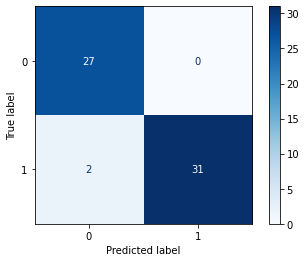

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.show()

View decision boundary

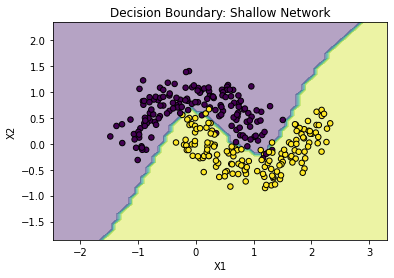

In [19]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

f, ax = plt.subplots()

Z = (model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0.5).astype('int')
Z = Z.reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.4)
ax.scatter(X[:, 0], X[:, 1], c = y, s=30, edgecolor="k")
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Decision Boundary: Shallow Network')
plt.show()

The model object returns a history method:
- history attribute is a dictionary storing:
   - training/validation losses.
   - metrics on train/validation sets.

In [20]:
train_loss = history.history['loss']
validation_loss = history.history['val_loss']
train_history = pd.DataFrame(history.history)
train_history.index.name = 'epochs'
train_history.head()

,loss,accuracy,auc,val_loss,val_accuracy,val_auc
epochs,,,,,,
0,0.640144,0.692708,0.820443,0.619091,0.750000,0.858929
1,0.619650,0.718750,0.860532,0.601368,0.750000,0.883036
2,0.600283,0.734375,0.883441,0.584372,0.770833,0.897321
3,0.582337,0.760417,0.897895,0.568220,0.770833,0.905357
4,0.565314,0.781250,0.906185,0.552912,0.750000,0.912500


Plotting history:

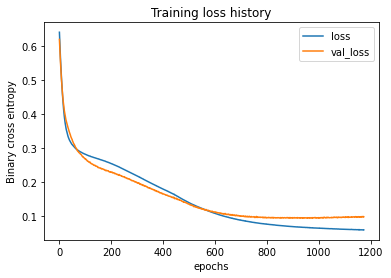

In [21]:
col_list = ['loss', 'val_loss']
train_history[col_list].plot()
plt.ylabel('Binary cross entropy')
plt.title('Training loss history')
plt.show()

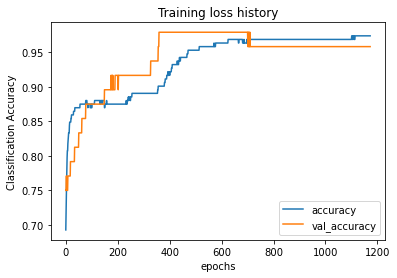

In [22]:
col_list = ['accuracy', 'val_accuracy']
train_history[col_list].plot()
plt.ylabel('Classification Accuracy')
plt.title('Training loss history')
plt.show()

#### Using neural networks to solve some harder problems

#### Image classificaton of hand-written digits

- The MNIST dataset: a classic benchmark for neural network image classification

In [23]:
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical # for target labels
from tensorflow.keras.layers import Flatten # takes 2D input and turns into 1D array

In [24]:
# load in the data
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

11493376/11490434 [==============================] - 1s 0us/step


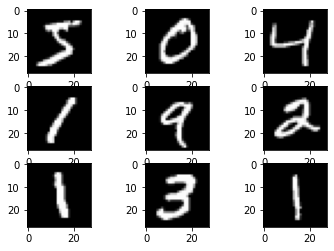

In [25]:
for i in range(9):  
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i], cmap=pyplot.get_cmap('gray'))
plt.show()

Good practice to normalize/standardize feature inputs:
- makes learning faster (optimization doesn't depend on variable scale)


<img src = "Images/normalize_nn.png" >

Another reason:
- keeping values small helps keeps weights stable

In [26]:
x_train = x_train/255 # normalization
x_test = x_test/255

# Keras requires multi-class labels to be one-hot encoded
y_tr_one_hot = to_categorical(y_train)
y_tt_one_hot = to_categorical(y_test)
y_tt_one_hot

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

#### Sequential model: add another hidden layer

- additional layer will help us learn more complex features
- note: we've added a few more units in first hidden layer as well.

In [27]:
model_images = Sequential()
model_images.add(Flatten(input_shape=(28, 28))) # flattens each 28x28 image into a vector
model_images.add(Dense(32, activation='relu'))
model_images.add(Dense(8, activation='relu'))
model_images.add(Dense(10, activation='softmax')) # number of units = number of target classes

In [28]:
model_images.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'] )

Let's train the model.

- Here we will use **validation** loss: stopping to prevent overfitting.

In [29]:
valcallback = EarlyStopping(monitor='val_loss', mode='min', verbose = 1, patience = 2)

In [30]:
history_mnist = model_images.fit(x_train, y_tr_one_hot, epochs=100, batch_size= 32, validation_split = 0.2, 
                 callbacks = [trainCallback] )

Epoch 1/100
1500/1500 [==============================] - 1s 748us/step - loss: 0.4916 - accuracy: 0.8571 - val_loss: 0.2512 - val_accuracy: 0.9268
Epoch 2/100
1500/1500 [==============================] - 1s 654us/step - loss: 0.2235 - accuracy: 0.9369 - val_loss: 0.1851 - val_accuracy: 0.9474
Epoch 3/100
1500/1500 [==============================] - 1s 658us/step - loss: 0.1716 - accuracy: 0.9517 - val_loss: 0.1708 - val_accuracy: 0.9507
Epoch 4/100
1500/1500 [==============================] - 1s 661us/step - loss: 0.1455 - accuracy: 0.9582 - val_loss: 0.1526 - val_accuracy: 0.9566
Epoch 5/100
1500/1500 [==============================] - 1s 659us/step - loss: 0.1281 - accuracy: 0.9623 - val_loss: 0.1468 - val_accuracy: 0.9578
Epoch 6/100
1500/1500 [==============================] - 1s 668us/step - loss: 0.1126 - accuracy: 0.9673 - val_loss: 0.1483 - val_accuracy: 0.9563
Epoch 7/100
1500/1500 [==============================] - 1s 665us/step - loss: 0.1029 - accuracy: 0.9694 - val_loss: 0

1500/1500 [==============================] - 1s 668us/step - loss: 0.0129 - accuracy: 0.9957 - val_loss: 0.2790 - val_accuracy: 0.9597
Epoch 55/100
1500/1500 [==============================] - 1s 690us/step - loss: 0.0117 - accuracy: 0.9964 - val_loss: 0.2997 - val_accuracy: 0.9578
Epoch 56/100
1500/1500 [==============================] - 1s 689us/step - loss: 0.0132 - accuracy: 0.9951 - val_loss: 0.3183 - val_accuracy: 0.9555
Epoch 57/100
1500/1500 [==============================] - 1s 669us/step - loss: 0.0112 - accuracy: 0.9966 - val_loss: 0.2792 - val_accuracy: 0.9617
Epoch 58/100
1500/1500 [==============================] - 1s 656us/step - loss: 0.0125 - accuracy: 0.9955 - val_loss: 0.2978 - val_accuracy: 0.9611
Epoch 59/100
1500/1500 [==============================] - 1s 661us/step - loss: 0.0111 - accuracy: 0.9962 - val_loss: 0.2913 - val_accuracy: 0.9608
Epoch 60/100
1500/1500 [==============================] - 1s 659us/step - loss: 0.0118 - accuracy: 0.9957 - val_loss: 0.3131 

In [31]:
# probability for each class
y_proba = model_images.predict(x_test)
y_proba

array([[8.6502656e-19, 4.1039092e-09, 6.8374421e-12, ..., 9.9999928e-01,
        8.4270898e-12, 4.1222910e-07],
       [0.0000000e+00, 2.1020249e-22, 1.0000000e+00, ..., 1.2549363e-38,
        9.1190466e-30, 6.4559731e-37],
       [1.9283750e-26, 9.9997544e-01, 2.4548817e-05, ..., 4.9626326e-08,
        2.3653681e-11, 9.7106818e-14],
       ...,
       [1.7929855e-21, 5.3336828e-37, 4.5526415e-25, ..., 8.4876666e-16,
        3.7417183e-24, 4.6102610e-18],
       [1.1128688e-15, 2.7441416e-22, 1.2436659e-30, ..., 3.2134511e-33,
        3.2126997e-09, 1.0099442e-23],
       [1.2331296e-25, 1.5567724e-24, 1.8555588e-17, ..., 0.0000000e+00,
        1.2713085e-24, 4.4605453e-35]], dtype=float32)

In [32]:
model_images.evaluate(x_test, y_tt_one_hot, verbose = 0)

[0.3484650254249573, 0.9588000178337097]

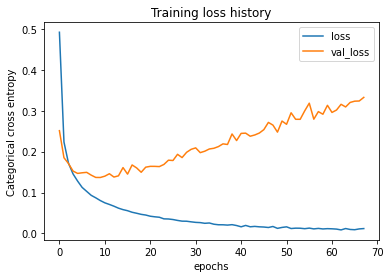

In [33]:
train_mnist_history = pd.DataFrame(history_mnist.history)
train_mnist_history.index.name = 'epochs'

col_list = ['loss', 'val_loss']
train_mnist_history[col_list].plot()
plt.ylabel('Categorical cross entropy')
plt.title('Training loss history')
plt.show()

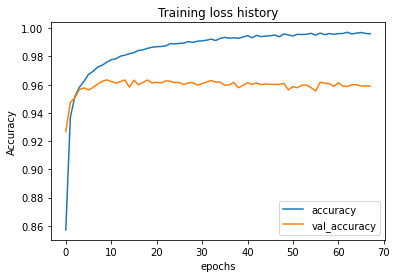

In [34]:
col_list = ['accuracy', 'val_accuracy']
train_mnist_history[col_list].plot()
plt.ylabel('Accuracy')
plt.title('Training loss history')
plt.show()

Clearly, some overfitting.

Getting the class predictions from softmax probabilities.

In [35]:
# argmax axis = -1 gets the column index of maximum probability for each row.
# column index corresponds to digit classes (numbers 0 -9)
predicted = np.argmax(y_proba, axis=-1)
predicted

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

Let's look at our classifier did on the test set in more detail.

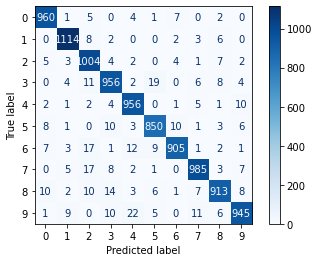

In [36]:
cm_digits = confusion_matrix(y_test, predicted)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_digits)

disp.plot(cmap=plt.cm.Blues)
plt.show()

Not bad:
- but in the context of many tasks this is not yet a viable system.
- e.g., reading checks, etc

- Next steps: increasing network complexity / train longer but not overfitting
- getting better fitting and test-set generalization

<center><b>Network Regularization</b></center>